# ***Verificación de supuestos del modelo ARIMA***

In [21]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
from scipy import stats
import numpy as np
# =========================
ipc = pd.read_csv('pizarras/parcial2/IPC.csv')
ipc_values = ipc['IPC'].values

lambda_bc = -1
x = np.asarray(ipc_values, dtype=float)
# Box–Cox λ = −1
y_bc = stats.boxcox(x, lmbda=lambda_bc)
y = np.diff(y_bc, n=2)


y = np.diff(stats.boxcox(x, lmbda=-1), n=2)

model = ARIMA(y, order=(0,0,1)).fit()   # ojo: si ya diferenciaste tú, d=0 aquí
residuals = model.resid

c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



**1. Modelo ARMA(0,2,1)**

$$
\nabla^2 T(\text{IPC}_t) = (1 - 0.6817B) \tilde{Z}_t
$$

Es decir:

$$
= \tilde{Z}_t  -0.6817 \tilde{Z}_{t-1}
$$

---

**Análisis de residuos**

**Supuesto 1: Errores con media cero**

- Hipótesis nula:  
  $H_0: \mu_{\varepsilon} = 0$

- Hipótesis alternativa:  
  $H_1: \mu_{\varepsilon} \ne 0$



**Estadístico de prueba:**

$$
t_0 = \frac{\bar{X}_{\varepsilon}}{S_{\varepsilon} / \sqrt{n}} \sim t(n - 1)
$$



**Resultado del test t (R output):**

```text
One Sample t-test

data:  resint_ARIMA021
t = -0.022657, df = 89, p-value = 0.982
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -9.79742e-05  9.73261e-05
sample estimates:
mean of x
-3.20478e-07




**Interpretación**

Como:

$$
p\text{-valor} = 0.982 > \alpha = 0.01
$$

**No tenemos suficiente evidencia estadística para rechazar que $\mu_{\varepsilon} = 0$**

Por lo tanto, **se verifica el supuesto de media cero** en los residuos.



---

 **Supuesto 2: La varianza de los errores es constante**

**i) Prueba de Breusch–Pagan**

- **$H_0$:** Homocedasticidad (varianza constante)

- **$H_1$:** Heterocedasticidad (varianza no constante)



**ii) Gráfico de residuos contra tiempo**

Este gráfico ayuda a detectar visualmente si la dispersión de los residuos varía a lo largo del tiempo.  
Si la nube de puntos se ensancha o estrecha sistemáticamente, puede haber heterocedasticidad.



**Prueba de Breusch–Pagan**

Se utiliza esta prueba para detectar si la varianza de los errores es constante (homocedasticidad) o cambia a lo largo del tiempo (heterocedasticidad).


 **Resultado del test (Breusch–Pagan studentizado)**

```text
studentized Breusch-Pagan test

data:  modelo
BP = 1.1253, df = 1, p-value = 0.2888


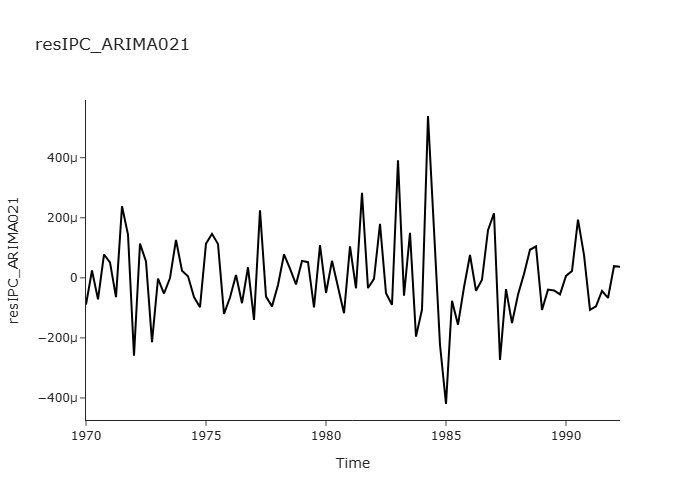

In [23]:
import numpy as np
import plotly.graph_objects as go

# y = serie transformada



errors = residuals  # <-- aquí pon TUS residuos reales
start_year = 1970
freq = 4

t = start_year + np.arange(len(errors)) / freq

fig = go.Figure()
fig.add_trace(go.Scatter(x=t, y=errors, mode="lines", line=dict(color="black")))
fig.update_layout(
    title="resIPC_ARIMA021",
    xaxis_title="Time",
    yaxis_title="resIPC_ARIMA021",
    template="simple_white",
    showlegend=False
)
fig.show()


---

**Supuesto 3: Los errores tienen distribución normal**



**i)** Pruebas de normalidad

**ii)** Histograma y gráfico Q-Q  

**iii)** Regla empírica (68-95-99.7%)  

**iiii)** Prueba de normalidad formal (Anderson–Darling)



**Test de Anderson–Darling**

- **Hipótesis nula**: $H_0$ = Normalidad  
- **Hipótesis alternativa**: $H_1$ = No normalidad

```text
Anderson-Darling normality test

data:  resIPC_ARIMA021
A = 1.235, p-value = 0.003061


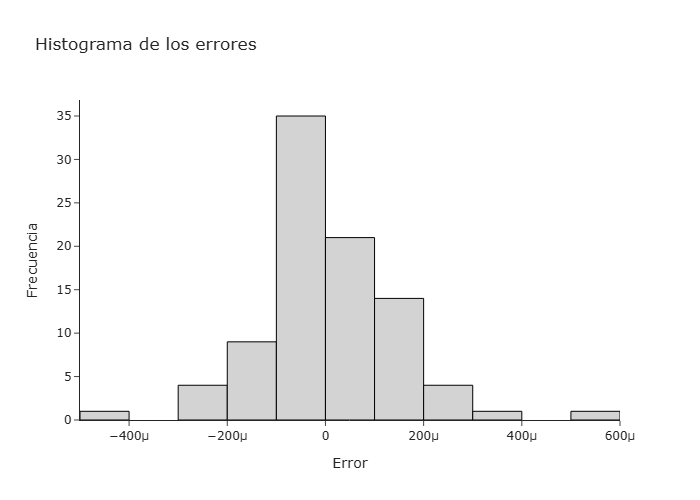

In [5]:
import numpy as np
import plotly.graph_objects as go
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=errors,
    nbinsx=10,
    marker=dict(color="lightgray", line=dict(color="black", width=1)),
    showlegend=False
))

fig.update_layout(
    title="Histograma de los errores",
    xaxis_title="Error",
    yaxis_title="Frecuencia",
    template="simple_white"
)

fig.show()


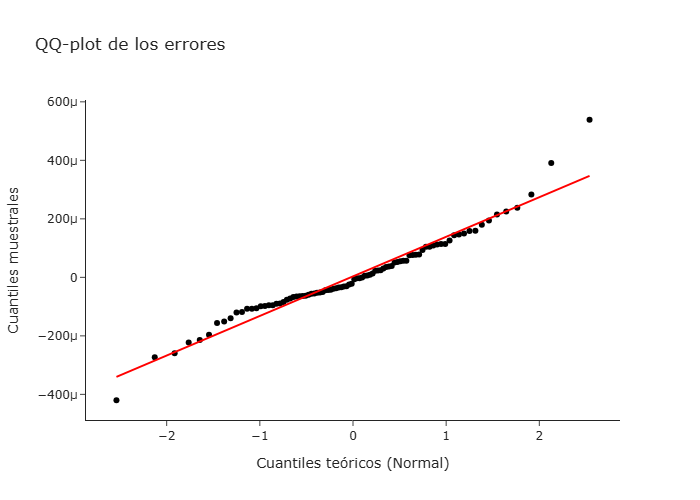

In [6]:
import numpy as np
import plotly.graph_objects as go
from scipy import stats

errors = model.resid
errors = errors[~np.isnan(errors)]

# cuantiles teóricos normales
n = len(errors)
theoretical_q = stats.norm.ppf((np.arange(1, n+1) - 0.5) / n)

# cuantiles muestrales
sample_q = np.sort(errors)

fig = go.Figure()

# puntos
fig.add_trace(go.Scatter(
    x=theoretical_q,
    y=sample_q,
    mode="markers",
    marker=dict(color="black", size=6),
    showlegend=False
))

# línea de referencia (como qqline en R)
slope, intercept, *_ = stats.linregress(theoretical_q, sample_q)
x_line = np.array([theoretical_q.min(), theoretical_q.max()])
y_line = intercept + slope * x_line

fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode="lines",
    line=dict(color="red"),
    showlegend=False
))

fig.update_layout(
    title="QQ-plot de los errores",
    xaxis_title="Cuantiles teóricos (Normal)",
    yaxis_title="Cuantiles muestrales",
    template="simple_white"
)

fig.show()


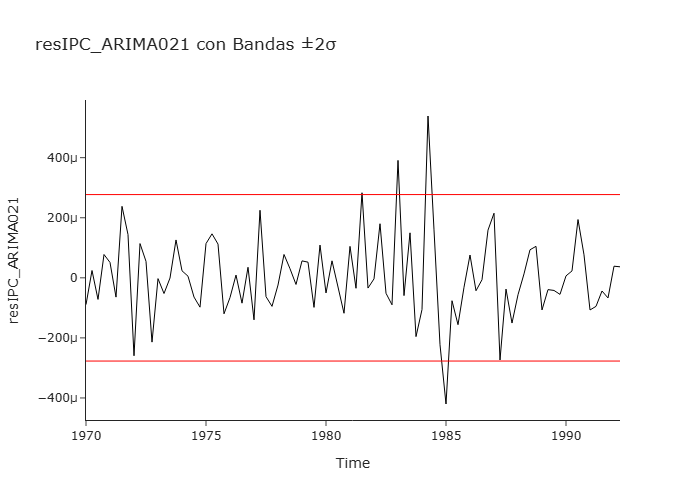

In [8]:
import numpy as np
import plotly.graph_objects as go

start_year = 1970
freq = 4
t = start_year + np.arange(len(errors)) / freq

sigma = np.std(errors, ddof=1)
upper = 2*sigma
lower = -2*sigma

fig = go.Figure()

# errores
fig.add_trace(go.Scatter(x=t, y=errors, mode="lines",
                         line=dict(color="black", width=1),
                         showlegend=False))

# bandas (como traces -> SIEMPRE se ven)
fig.add_trace(go.Scatter(x=t, y=np.full_like(t, upper),
                         mode="lines", line=dict(color="red", width=1),
                         showlegend=False))
fig.add_trace(go.Scatter(x=t, y=np.full_like(t, lower),
                         mode="lines", line=dict(color="red", width=1),
                         showlegend=False))

fig.update_layout(
    title="resIPC_ARIMA021 con Bandas ±2σ",
    xaxis_title="Time",
    yaxis_title="resIPC_ARIMA021",
    template="simple_white"
)

fig.show()





- **Hipótesis nula:** $H_0$ = normalidad  
- **Hipótesis alternativa:** $H_1$ = no normalidad



**Resultado del test de normalidad**

- Se utilizó el test de **Anderson–Darling**
- Se obtuvo un **p-valor = 0.003**
- Nivel de significancia $\alpha = 0.01$

**Interpretación**

Como:

$$
\text{p-valor} = 0.003 < \alpha = 0.01
$$

Rechazamos $H_0$ y aceptamos $H_1$ con un 99% de confianza.

**Por lo tanto, no se verifica el supuesto de normalidad.**

---




**Supuesto 4: Errores independientes**

**i)** Prueba de Box–Pierce / Ljung–Box  
**ii)** Autocorrelaciones de los residuos


c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



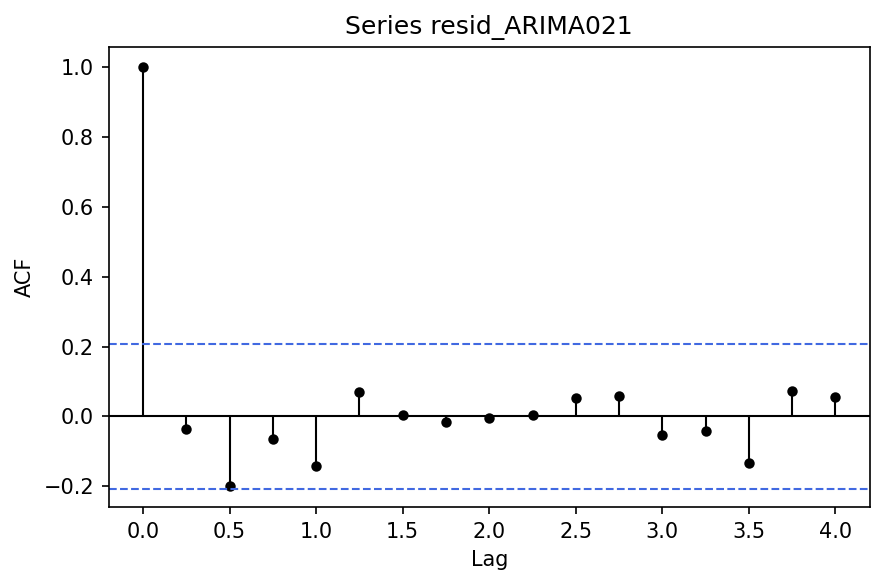

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf


# ========= CONFIG =========
freq = 4          # frecuencia (para que el eje Lag vaya 0–4 como en R)
nlags_cycles = 4  # número de ciclos (4 ciclos * freq = 16 lags)
# ==========================


def resid_acf_plot(resid, title):
    resid = np.asarray(resid, dtype=float)
    resid = resid[~np.isnan(resid)]

    n = len(resid)
    nlags = int(freq * nlags_cycles)

    acf_vals = acf(resid, nlags=nlags, fft=False)
    lags = np.arange(len(acf_vals))

    ci = 1.96 / np.sqrt(n)
    x = lags / freq

    plt.figure(figsize=(6, 4), dpi=150)

    # stems
    plt.vlines(x, 0, acf_vals, colors="black", linewidth=1)
    plt.plot(x, acf_vals, "o", color="black", markersize=4)

    # reference lines
    plt.axhline(0, color="black", linewidth=1)
    plt.axhline(ci, color="royalblue", linestyle="--", linewidth=1)
    plt.axhline(-ci, color="royalblue", linestyle="--", linewidth=1)

    plt.xlabel("Lag")
    plt.ylabel("ACF")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =====================================================
# OPCIÓN A: y ya transformada → ARIMA(0,0,1)
# =====================================================
res = ARIMA(y, order=(0,0,1), trend="n").fit()





# ========= PLOT =========
resid_acf_plot(res.resid, title="Series resid_ARIMA021")


$$
\text{Box--Pierce test: } X^2 = 1.2101,\ df = 1,\ p\text{-value} = 0.2713
$$


**Hipótesis**

- $H_0$: independencia  
- $H_1$: no independencia



**Resultados**

Se aplicó la prueba de **Box–Pierce / Ljung–Box** sobre los residuos.

- Se obtuvo un **p-valor > \alpha**
- Nivel de significancia: $\alpha$

**Conclusión**

Como:

$$
\text{p-valor} > \alpha
$$

**No tenemos suficiente evidencia estadística para rechazar $H_0$**
 Por lo tanto, se **verifica el supuesto de independencia**.


Además, el **gráfico de las autocorrelaciones muestrales de los residuos** confirma visualmente la verificación de este supuesto, ya que **todas las barras se encuentran dentro del intervalo de confianza**.

---


**Supuesto 5: Parsimonia e inferencia sobre los parámetros**

**Principio de parsimonia**

El **principio de parsimonia** indica que **el mejor modelo** es aquel que **utiliza la menor cantidad posible de parámetros** para explicar adecuadamente el fenómeno en estudio.

En otras palabras, **menos es más**:  
Debe preferirse un modelo más simple si explica los datos casi igual de bien que uno más complejo.

**Inferencia sobre los parámetros**

Una forma de verificar la **significancia de los parámetros estimados** es analizando sus **intervalos de confianza al 95%**.


**Ejemplo**:

```text
             2.5 %           97.5 %
ma1      -0.8633673442   -0.5001092211
intercept 0.0002062849    0.0002073526

